# DSAI 490 - Assignment 1: Autoencoders (AE & VAE)

### Instructions:
1. **غيّر الـ runtime لـ GPU أول حاجة:** Runtime > Change runtime type > T4 GPU
2. ارفع `project.zip` في الـ cell الأولى
3. ارن كل الـ cells بالترتيب

## GPU Verification Cell
This cell checks if the GPU is available and being used by TensorFlow.

In [1]:
import tensorflow as tf
import os

# Check if GPU is available
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f'✅ GPU is available: {physical_devices}')
    # Set memory growth to avoid allocating all memory at once
    try:
        for device in physical_devices:
            tf.config.experimental.set_memory_growth(device, True)
        print('✅ Memory growth enabled')
    except Exception as e:
        print(f'❌ Error enabling memory growth: {e}')

    # Print GPU details
    print("GPU Details:")
    os.system('nvidia-smi -L')
else:
    print('❌ GPU is NOT available. Please check your runtime settings.')

# Verify TensorFlow is using the GPU
print(f'TensorFlow version: {tf.__version__}')
print(f'Is built with CUDA: {tf.test.is_built_with_cuda()}')
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('❌ GPU device not found by TensorFlow')
else:
    print(f'✅ Found GPU at: {device_name}')

✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth enabled
GPU Details:
TensorFlow version: 2.19.0
Is built with CUDA: True
✅ Found GPU at: /device:GPU:0


## Cell 1 — Upload & Unzip Project

In [2]:
from google.colab import files
import os

print('Please upload project.zip ...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f'Uploaded: {zip_name}')

Please upload project.zip ...


Saving project.zip to project.zip
Uploaded: project.zip


In [3]:
import subprocess
subprocess.run(['unzip', '-o', f'/content/{zip_name}', '-d', '/content/'], check=True)
print('\nProject structure:')
!find /content/project -type f | sort


Project structure:
/content/project/notebooks/DSAI490_Assignment1_Runner.ipynb
/content/project/README.md
/content/project/requirements.txt
/content/project/src/data_processing.py
/content/project/src/__init__.py
/content/project/src/model.py
/content/project/src/train.py
/content/project/tests/test_data_processing.py
/content/project/tests/test_model.py


## Cell 2 — Install Requirements

In [4]:
!pip install -r /content/project/requirements.txt -q
print('All packages installed!')

All packages installed!


## Cell 3 — Mount Google Drive & Download Dataset

In [5]:
from google.colab import drive
import os, shutil, kagglehub

drive.mount('/content/drive')

DRIVE_DATA_DIR = '/content/drive/MyDrive/medical-mnist'

if not os.path.exists(DRIVE_DATA_DIR):
    print('Downloading dataset from Kaggle...')
    os.environ['KAGGLEHUB_VERIFY_SSL'] = '0'
    temp_path = kagglehub.dataset_download('andrewmvd/medical-mnist')
    print('Downloaded to:', temp_path)
    shutil.copytree(temp_path, DRIVE_DATA_DIR)
    print('Saved to Google Drive.')
else:
    print('Dataset already in Drive:', DRIVE_DATA_DIR)

Mounted at /content/drive
Dataset already in Drive: /content/drive/MyDrive/medical-mnist


## Cell 3b — Copy Dataset to Local Storage (أسرع بكتير من Drive)

In [6]:
import shutil, os

LOCAL_DATA = '/content/medical-mnist'

if not os.path.exists(LOCAL_DATA):
    print('Copying dataset from Drive to local storage...')

    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA)
    print('Done! Dataset copied to local.')
else:
    print('Local dataset already exists:', LOCAL_DATA)

# عدد الصور
total = sum(len(files) for _, _, files in os.walk(LOCAL_DATA))
print(f'Total images: {total}')

Copying dataset from Drive to local storage...
Done! Dataset copied to local.
Total images: 58954


## Cell 4 — Load & Preprocess Data

In [7]:
import sys
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

sys.path.insert(0, '/content/project')

def load_and_preprocess_data(data_dir, img_size=(64, 64), batch_size=32):
    """Load data from LOCAL storage with cache() for fast training."""
    class_names = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    image_paths, labels = [], []

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
                image_paths.append(os.path.join(class_path, img_name))
                labels.append(i)

    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )

    def process_path(file_path, label):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=1)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0
        return img, img

    train_ds = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
                .map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
                .cache()                   # ← يحمل الداتا في RAM مرة واحدة
                .shuffle(1000)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

    test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
               .map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
               .cache()                    # ← نفس الشيء
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return train_ds, test_ds, class_names


train_ds, test_ds, class_names = load_and_preprocess_data(LOCAL_DATA)
print('Classes found:', class_names)
print('Data loaded successfully!')

Classes found: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Data loaded successfully!


## Cell 5 — Build Models

In [8]:
from src.model import build_ae, build_vae

latent_dim = 32

# Build AE
ae_model, ae_encoder, ae_decoder = build_ae(latent_dim)
ae_model.compile(optimizer='adam', loss='mse')
print('=== Autoencoder ===')
ae_model.summary()

# Build VAE
vae_encoder, vae_decoder = build_vae(latent_dim)
print('\n=== VAE Encoder ===')
vae_encoder.summary()
print('\n=== VAE Decoder ===')
vae_decoder.summary()

=== Autoencoder ===


Model: "AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       543,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 64, 64, 1)      │       596,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139,489 (4.35 MB)

 Trainable params: 1,139,489 (4.35 MB)

...

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16384)          │       540,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,353 (2.27 MB)

 Trainable params: 596,353 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 6 — Train AE

In [17]:
epochs = 50

print('Training Autoencoder (AE)...')

ae_model.fit(train_ds, epochs=epochs, validation_data=test_ds)
print('AE training complete!')

Training Autoencoder (AE)...
Epoch 1/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0049 - val_loss: 0.0051
Epoch 2/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 3/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 4/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 5/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0045 - val_loss: 0.0048
Epoch 6/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0044 - val_loss: 0.0051
Epoch 7/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 8/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 9/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0042 - val_loss: 0.0047
Epoch 10/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 11/50
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0041 - val_los

## Cell 7 — Train VAE

In [21]:
## Cell 7 — Train VAE (Fixed Custom Loop)
import tensorflow as tf
from src.model import build_vae
import time

print('Training Variational Autoencoder (VAE)...')

# 1. Reset and Rebuild to ensure a clean state
tf.keras.backend.clear_session()
vae_encoder, vae_decoder = build_vae(latent_dim)

# 2. Define Optimizer OUTSIDE the training step
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# 3. Define the loss function (matching VAE logic)
def compute_vae_loss(images, encoder, decoder):
    z_mean, z_log_var, z = encoder(images)
    reconstruction = decoder(z)

    # Reconstruction loss (MSE)
    reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(tf.keras.losses.mse(images, reconstruction), axis=(1, 2))
    )

    # KL Divergence loss
    kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
    kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

    return reconstruction_loss + kl_loss

# 4. Define the training step with @tf.function
@tf.function
def train_step(images):
    with tf.GradientTape() as tape:
        loss = compute_vae_loss(images, vae_encoder, vae_decoder)

    trainable_vars = vae_encoder.trainable_variables + vae_decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    optimizer.apply_gradients(zip(gradients, trainable_vars))
    return loss

# 5. Manual Training Loop
epochs = 50
for epoch in range(epochs):
    start_time = time.time()
    total_loss = 0
    num_batches = 0

    for batch_images, _ in train_ds:
        loss = train_step(batch_images)
        total_loss += loss
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - time: {time.time() - start_time:.2f}s")

print('VAE training complete!')


Training Variational Autoencoder (VAE)...
Epoch 1/50 - loss: 99.8020 - time: 14.53s
Epoch 2/50 - loss: 65.1893 - time: 12.23s
Epoch 3/50 - loss: 61.6554 - time: 11.92s
Epoch 4/50 - loss: 59.7605 - time: 11.64s
Epoch 5/50 - loss: 58.4772 - time: 11.57s
Epoch 6/50 - loss: 57.5015 - time: 11.63s
Epoch 7/50 - loss: 56.7505 - time: 11.76s
Epoch 8/50 - loss: 56.1174 - time: 11.97s
Epoch 9/50 - loss: 55.4975 - time: 11.90s
Epoch 10/50 - loss: 55.0992 - time: 11.68s
Epoch 11/50 - loss: 54.6983 - time: 11.66s
Epoch 12/50 - loss: 54.4049 - time: 11.67s
Epoch 13/50 - loss: 54.0124 - time: 11.73s
Epoch 14/50 - loss: 53.7962 - time: 11.79s
Epoch 15/50 - loss: 53.4934 - time: 11.83s
Epoch 16/50 - loss: 53.3451 - time: 11.71s
Epoch 17/50 - loss: 53.0192 - time: 11.71s
Epoch 18/50 - loss: 52.9022 - time: 11.68s
Epoch 19/50 - loss: 52.6662 - time: 11.71s
Epoch 20/50 - loss: 52.5027 - time: 11.73s
Epoch 21/50 - loss: 52.3610 - time: 11.68s
Epoch 22/50 - loss: 52.2219 - time: 11.68s
Epoch 23/50 - loss: 5

## Cell 8 — Reconstruct & Visualize

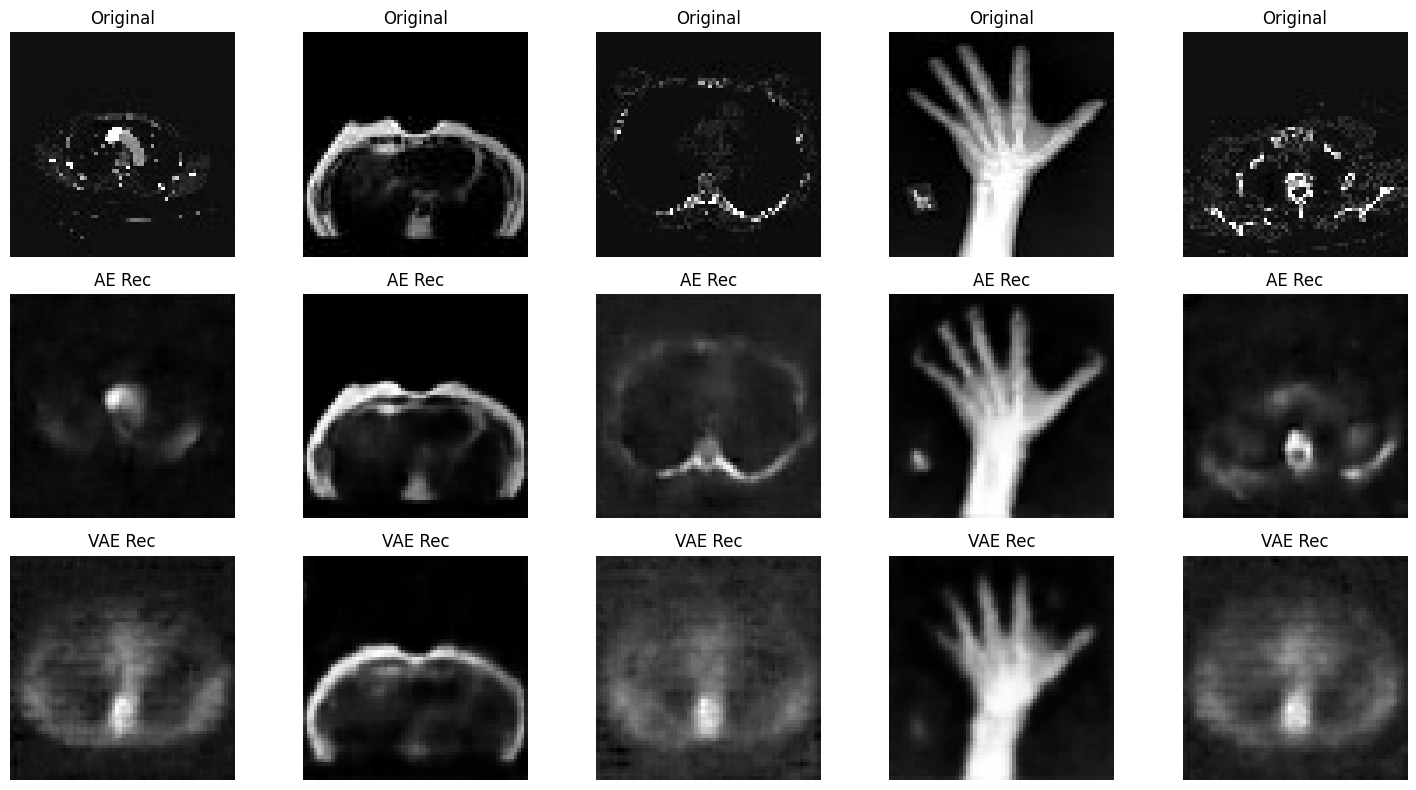

In [22]:
import matplotlib.pyplot as plt

def plot_results(ae_model, vae_encoder, vae_decoder, dataset):
    images, _ = next(iter(dataset))
    ae_recs = ae_model(images)
    _, _, z = vae_encoder(images)
    vae_recs = vae_decoder(z)

    plt.figure(figsize=(15, 8))
    for i in range(5):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.title('Original'); plt.axis('off')

        plt.subplot(3, 5, i + 6)
        plt.imshow(ae_recs[i, :, :, 0], cmap='gray')
        plt.title('AE Rec'); plt.axis('off')

        plt.subplot(3, 5, i + 11)
        plt.imshow(vae_recs[i, :, :, 0], cmap='gray')
        plt.title('VAE Rec'); plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_results(ae_model, vae_encoder, vae_decoder, test_ds)

## Cell 9 — Latent Space Visualization

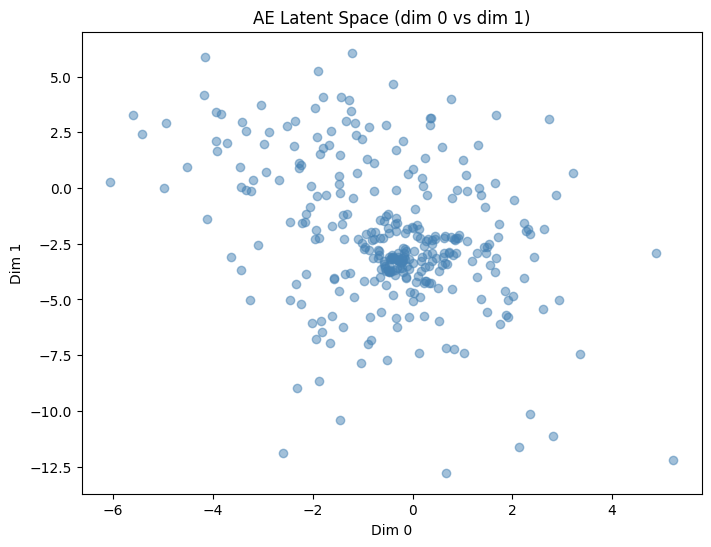

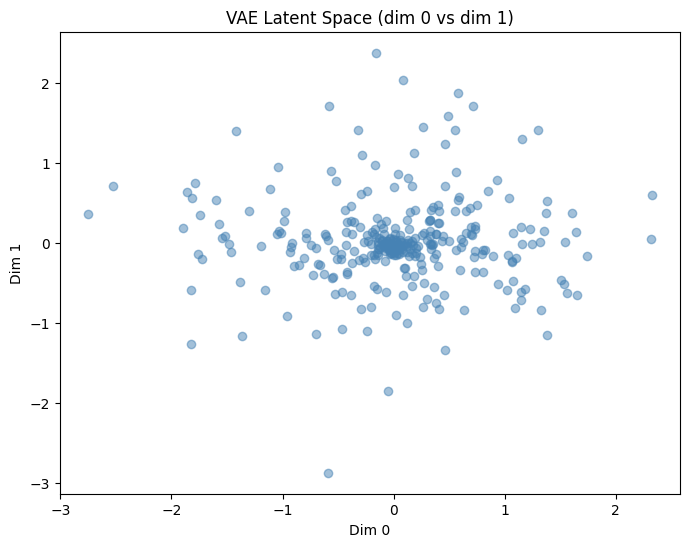

In [23]:
import numpy as np

def plot_latent(encoder, dataset, title, is_vae=False):
    latents = []
    for images, _ in dataset.take(10):
        res = encoder(images)
        z = res[0] if is_vae else res
        latents.append(z.numpy())
    latents = np.concatenate(latents, axis=0)

    plt.figure(figsize=(8, 6))
    plt.scatter(latents[:, 0], latents[:, 1], alpha=0.5, c='steelblue')
    plt.title(f'{title} Latent Space (dim 0 vs dim 1)')
    plt.xlabel('Dim 0'); plt.ylabel('Dim 1')
    plt.show()

plot_latent(ae_encoder, test_ds, 'AE')
plot_latent(vae_encoder, test_ds, 'VAE', is_vae=True)

## Cell 10 — Generate New Samples (VAE)

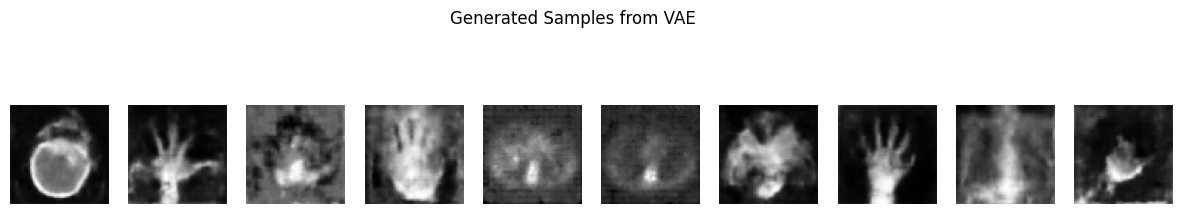

In [24]:
def generate_vae_samples(decoder, n=10, latent_dim=32):
    z_samples = tf.random.normal(shape=(n, latent_dim))
    gen_images = decoder(z_samples)

    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(gen_images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle('Generated Samples from VAE')
    plt.show()

generate_vae_samples(vae_decoder, latent_dim=latent_dim)

## Cell 11 — Denoising Test

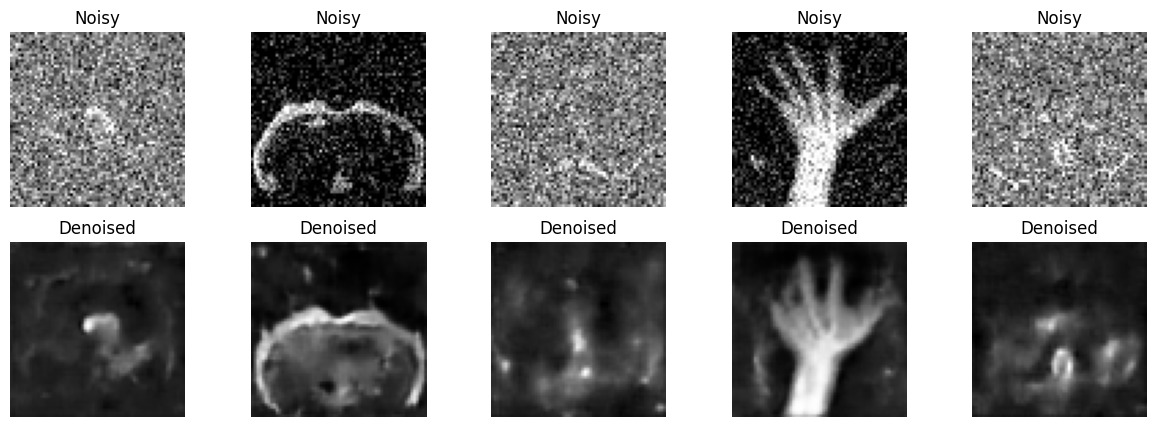

In [25]:
def test_denoising(model, dataset):
    images, _ = next(iter(dataset))
    noisy = tf.clip_by_value(images + 0.2 * tf.random.normal(shape=tf.shape(images)), 0.0, 1.0)
    denoised = model(noisy)

    plt.figure(figsize=(15, 5))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(noisy[i, :, :, 0], cmap='gray')
        plt.title('Noisy'); plt.axis('off')

        plt.subplot(2, 5, i + 6)
        plt.imshow(denoised[i, :, :, 0], cmap='gray')
        plt.title('Denoised'); plt.axis('off')
    plt.show()

test_denoising(ae_model, test_ds)

## Cell 12 — Run Unit Tests

In [26]:
!python -m pytest /content/project/tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: langsmith-0.7.30, typeguard-4.5.1, anyio-4.13.0
collected 9 items                                                              

project/tests/test_data_processing.py::TestDataProcessing::test_batch_size PASSED [ 11%]
project/tests/test_data_processing.py::TestDataProcessing::test_normalization PASSED [ 22%]
project/tests/test_data_processing.py::TestDataProcessing::test_output_shape PASSED [ 33%]
project/tests/test_model.py::TestAEModel::test_ae_output_shape PASSED    [ 44%]
project/tests/test_model.py::TestAEModel::test_decoder_output_shape PASSED [ 55%]
project/tests/test_model.py::TestAEModel::test_encoder_latent_shape PASSED [ 66%]
project/tests/test_model.py::TestVAEModel::test_vae_decoder_output_shape PASSED [ 77%]
project/tests/test_model.py::TestVAEModel::test_vae_enc